$
\def\D{\Omega}
\def\ipar{m}
\def\R{\mathbb{R}}
\def\del{\partial}
\def\vec{\bf}
\def\priorm{\mu_0}
\def\C{\mathcal{C}}
\def\Acal{\mathcal{A}}
\def\postm{\mu_{\rm{post}}}
\def\iparpost{\ipar_\text{post}}
\def\obs{ {\vec d}} 
\def\yobs{\obs^{\text{obs}}}
\def\obsop{\mathcal{B}}
\def\dd{\vec{\bar{d}}}
\def\iFF{\mathcal{F}}
\def\iFFadj{\mathcal{F}^*}
\def\ncov{\Gamma_{\mathrm{noise}}}
$
# Bayesian initial condition inversion in an advection-diffusion problem 




### The forward problem:

The parameter-to-observable map $\iFF \,\ipar := \obsop\, u(\ipar)$ maps an initial condition $\ipar \in L^2(\D)$ to pointwise spatiotemporal observations of the concentration field $u({\vec x},t)$ through solution of the advection-diffusion equation given by

$$
\begin{split}
u_t - \kappa\Delta u + {\vec v} \cdot \nabla u &= 0     & \quad \text{in } \D\times(0,T),\\
                                 u(\cdot, 0) &= \ipar & \quad \text{in } \D,\\
                \kappa \nabla u\cdot {\vec{n}} &= 0     & \quad \text{on } \partial\D \times (0,T).
\end{split}
$$

Here, $\D \subset \R^d$ ($d \in \{2, 3\}$) is a bounded domain, $\kappa > 0$ is the diffusion coefficient and $T > 0$ is the final
time. The velocity field
$\vec{v}$ is computed by solving the following steady-state
Navier-Stokes equation with the side walls driving the flow:

$$
\begin{aligned}
- \frac{1}{\operatorname{Re}} \Delta {\vec v} + \nabla q + {\vec v} \cdot \nabla {\vec v} &= 0 &\quad&\text{ in }\D,\\
\nabla \cdot {\vec v} &= 0 &&\text{ in }\D,\\
{\vec v} &= {\vec g} &&\text{ on } \partial\D.
\end{aligned}
$$

Here, $q$ is pressure, $\text{Re}$ is the Reynolds number. The Dirichlet boundary data
${\vec g} \in \R^d$ is given by 
${\vec g} = {\vec e}_2$ on the left wall of the domain, 
${\vec g}=-{\vec e}_2$ on the right wall,  and ${\vec g} = {\vec 0}$ everywhere else.


## 1. Load modules

In [1]:
import dolfin as dl
#import ufl
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.linalg
from scipy.integrate import trapezoid
%matplotlib inline
import sys
import os
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "../") )
sys.path.insert(1, '/mnt/c/Users/Sonia/Documents/Courant/Research/INLA/hippylib')
from hippylib import *
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "..") + "/applications/ad_diff/" )
from model_ad_diff import SpaceTimePointwiseStateObservation

# modified hippylib code
from model_ad_diff_modified import TimeDependentAD # makes kappa no longer hardcoded
from posterior_modified import * # adds version for unpreconditioned low rank decomp
from prior_modified import * # changes Krylov solvers to LU/Cholesky for speed

import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
#logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

import time
import line_profiler
%load_ext line_profiler
np.random.seed(42)

## 2. Construct the velocity field

In [2]:
# All from original AdvectionDiffusionBayesian tutorial
def v_boundary(x,on_boundary):
    return on_boundary

def q_boundary(x,on_boundary):
    return x[0] < dl.DOLFIN_EPS and x[1] < dl.DOLFIN_EPS
        
def computeVelocityField(mesh):
    Xh = dl.VectorFunctionSpace(mesh,'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = dl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(1e2)
    
    g = dl.Expression(('0.0','(x[0] < 1e-14) - (x[0] > 1 - 1e-14)'), degree=1)
    bc1 = dl.DirichletBC(XW.sub(0), g, v_boundary)
    
    bc2 = dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise')
    bcs = [bc1, bc2]
    
    vq = dl.Function(XW)
    (v,q) = dl.split(vq)
    (v_test, q_test) = dl.TestFunctions (XW)
    
    def strain(v):
        return dl.sym(dl.grad(v))
    
    F = ( (2./Re)*dl.inner(strain(v),strain(v_test))+ dl.inner (dl.nabla_grad(v)*v, v_test)
           - (q * dl.div(v_test)) + ( dl.div(v) * q_test) ) * dl.dx
           
    dl.solve(F == 0, vq, bcs, solver_parameters={"newton_solver":
                                         {"relative_tolerance":1e-4, "maximum_iterations":100}})
    
#     plt.figure(figsize=(15,5))
#     vh = dl.project(v,Xh)
#     qh = dl.project(q,Wh)
#     nb.plot(nb.coarsen_v(vh), subplot_loc=121,mytitle="Velocity")
#     nb.plot(qh, subplot_loc=122,mytitle="Pressure")
#     plt.show()
        
    return v

## 3. Set up the mesh and finite element spaces

In [3]:
# number of degrees of freedom in mesh (selects which mesh to import)
# current options are 253, 399, 557, 605, 729, 1225, 1879, 2363, 2779, 5443, 8335, 11521
dofs = 729

# number of time steps for forward solve
nt = 20

In [4]:
mesh = dl.refine( dl.Mesh("adv_diff_dofs_{0}.xml".format(dofs)) )
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
print( "Number of dofs: {0}".format( Vh.dim() ) )

Number of dofs: 729


## 4. Set up true initial condition

In [5]:
ic_expr = dl.Expression(
    'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
    element=Vh.ufl_element())

true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
    
t_init         = 0.
t_final        = 4.
t_1            = 1.
dt             = t_final/nt #.1
#observation_dt = .2
observation_dt = 0.4 #1.6
    
simulation_times = np.arange(t_init, t_final+.5*dt, dt)
observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)


# # targets along building edges
# targets = np.loadtxt('targets.txt')

pts = 4 # number of observation points on each side of the buildings
targets = np.zeros((8*pts,2))
targets[0:pts,0] = np.linspace(.25, .5, pts+2)[1:-1]
targets[0:pts,1] = 0.149
targets[pts:2*pts,0] = np.linspace(.25, .5, pts+2)[1:-1]
targets[pts:2*pts,1] = 0.401
targets[2*pts:3*pts,0] = 0.249
targets[2*pts:3*pts,1] = np.linspace(.15, .4, pts+2)[1:-1]
targets[3*pts:4*pts,0] = 0.501
targets[3*pts:4*pts,1] = np.linspace(.15, .4, pts+2)[1:-1]
targets[4*pts:5*pts,0] = np.linspace(.6, .75, pts+2)[1:-1]
targets[4*pts:5*pts,1] = 0.599
targets[5*pts:6*pts,0] = np.linspace(.6, .75, pts+2)[1:-1]
targets[5*pts:6*pts,1] = 0.851
targets[6*pts:7*pts,0] = 0.599
targets[6*pts:7*pts,1] = np.linspace(.6, .85, pts+2)[1:-1]
targets[7*pts:8*pts,0] = 0.751
targets[7*pts:8*pts,1] = np.linspace(.6, .85, pts+2)[1:-1]

# print(targets)

print ("Number of observation points: {0}".format(targets.shape[0]) )
print ("Number of observation times: {0}".format(observation_times.shape[0]) )
# initialize observations
misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)

Number of observation points: 32
Number of observation times: 8


## 5. Generate the synthetic observations

In [6]:
# diffusivity
kappa_true = 0.001

# the code as written requires a prior to be passed in, but this should not be used in generating the observations
gamma = 1.
delta = 8.
# initialize prior w/ covariance C = (delta * I - gamma * Laplacian)^{-2}
prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
# constant mean
prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()

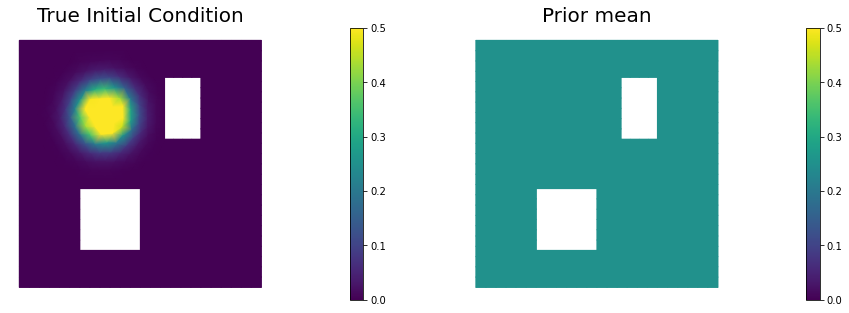

In [7]:
objs = [dl.Function(Vh,true_initial_condition),
        dl.Function(Vh,prior.mean)]
mytitles = ["True Initial Condition", "Prior mean"]
nb.multi1_plot(objs, mytitles)
plt.show()

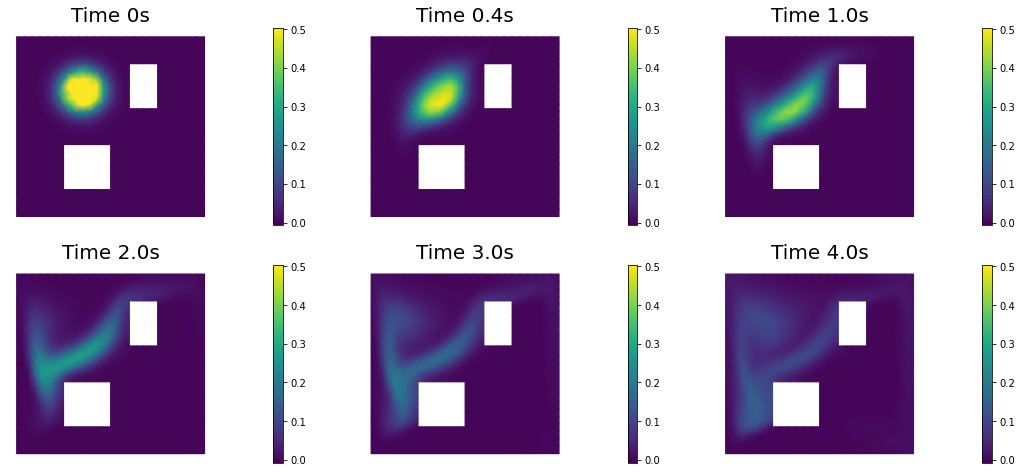

In [8]:
problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
# relative noise level
rel_noise = 0.01

# initialize vector in the state space
utrue = problem_true.generate_vector(STATE)
x = [utrue, true_initial_condition, None]

# solve forward problem
problem_true.solveFwd(x[STATE], x)

# observe solution and add error
misfit.observe(x, misfit.d)
MAX = misfit.d.norm("linf", "linf")
noise_std_dev = rel_noise * MAX
parRandom.normal_perturb(noise_std_dev,misfit.d)

misfit.noise_variance = noise_std_dev*noise_std_dev

# plot solution
nb.show_solution(Vh, true_initial_condition, utrue, "Solution")
plt.savefig("forward_solution.pdf",pad_inches=1)

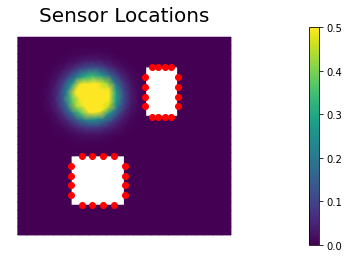

In [9]:
# plot target locations
nb.plot(dl.Function(Vh,true_initial_condition),mytitle='Sensor Locations')
plt.scatter(targets[:,0],targets[:,1],color='red')

In [10]:
def ComputePosterior(mesh, Vh, lmbda, V, pregamma, predelta, misfit, simulation_times, kappa, wind_velocity, gamma, delta):
    '''
    Solve inverse problem
    Output: posterior object and mg = mu_u0^T Q_u0 + u_d^T Q_eps A
    Input: mesh and finite element space Vh, 
            lmbda, V: low rank decomp of Q_pre^-1/2 A^T Q_eps A Q_pre^-1/2, where Q_pre is a preconditioning prior precision
            pregamma and predelta: parameters of Q_pre (or "none" if no Q_pre preconditioner)
            misfit: observed data
            simulation_times: times at which to compute forward solution
            kappa, wind_velocity: parameters of forward solution
            gamma, delta: hyperparameters of prior
    '''
    
    prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
    prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p]) # these last three lines don't use the prior and could be precomputed
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg) # this involves the prior so we should compute it here
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True) 
    
    if pregamma is None or predelta is None:
        posterior = GaussianLRPosterior(prior, lmbda, V, False)
        lmbda_new = lmbda
        V_new = V
    elif pregamma == gamma and predelta == delta:
        posterior = GaussianLRPosterior(prior, lmbda, V, True)
        lmbda_new = lmbda
        V_new = V
    else:
        preprior = BiLaplacianPrior(Vh, pregamma, predelta, robin_bc=True)
        preprior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
        # apply sqrt precon prior precision and sqrt inverse of prior precision
        Wtemp = MultiVector(V)
        Wtemp2 = MultiVector(V)
        W = MultiVector(V)
        for i in range(V.nvec()):
            preprior.A.mult(V[i],Wtemp[i]) # modifies Wtemp
            preprior.Msolver.solve(Wtemp2[i],Wtemp[i]) # modifies Wtemp2
            preprior.A.mult(Wtemp2[i],W[i]) # modifies W
        H_temp = LowRankOperator(lmbda, W)
        k = 160 #may want to set this to ~3/4 size of V instead of hardcoding
        pad = 20 
        Omega = MultiVector(x[PARAMETER], k+pad)
        parRandom.normal(1., Omega)
        lmbda_new, V_new = singlePassG(H_temp, prior.R, prior.Rsolver, Omega, k)
        posterior = GaussianLRPosterior(prior, lmbda_new, V_new, True)

#     Compute posterior mean
    H.misfit_only = False
    solver = CGSolverSteihaug()
    solver.set_operator(H) # use lmbda, V plus the prior here?
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
    posterior.mean = m
    
#     H = posterior.Hlr
#     H.solve(m,-mg)
#     posterior.mean = m

#     nb.plot(dl.Function(Vh,m))
    
    return posterior,mg,lmbda_new,V_new

In [11]:
# hyperprior parameters (independent gamma distributions in gamma and delta, shifted to start or end at min/max values)
alpha_del = 1
alpha_gam = 1
beta_del = 1e-4
beta_gam = 1e-4

max_del = 100
min_gam = 0.1

# fixing kappa
kappa = kappa_true

In [12]:
# -log pi(gamma, delta | u_d) (- log posterior marginal joint pdf of gamma, delta)
def neglogpi_gamma_delta(mesh, Vh, misfit, wind_velocity, lmbda, V, pregamma, predelta, kappa, gamma, delta):
    # compute new posterior
    posterior,mg,lmbda_new,V_new = ComputePosterior(mesh, Vh, lmbda, V, pregamma, predelta, misfit, simulation_times, kappa, wind_velocity, gamma, delta)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    if pregamma is None or predelta is None:
        # Bhelp = Q_u0^-1 * V
        Bhelp = MultiVector(V_new)
        for i in range(V_new.nvec()):
            posterior.prior.Rsolver.solve(Bhelp[i],V_new[i])
        # B = diag(lmbda) * V^T Q_u0^-1 V + I
        B = V_new.dot_mv(Bhelp)
        for i in range(B.shape[0]):
            B[i,:] *= lmbda_new[i]
            B[i,i] += 1.
        Bvals = np.linalg.eigvals(B)
        det_ratio = np.sum(np.log(Bvals)) - (alpha_del-1)*np.log(delta) - (alpha_gam-1)*np.log(gamma)
    else:
        det_ratio = 0.0
        for ll in posterior.d:
            det_ratio += np.log(1+ll)
    # -log pdf of gamma, delta prior
    gamma_delta_prior = beta_del*delta + beta_gam*gamma
    # set prior value to 0 outside the domain of the prior (neg log value to large)
    if gamma < min_gam or delta > max_del:
        gamma_delta_prior = 1e30
    # kappa_prior = 0.5*(q_kappa**2)*(np.log10(kappa)-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast 
    uQu = 0.5*mg.inner(posterior.mean)
    # - mu_0 Q_u0 mu_0
    Qmu = dl.Vector(posterior.prior.R.mpi_comm())
    posterior.prior.init_vector(Qmu,0)
    posterior.prior.R.mult(posterior.prior.mean,Qmu)
    muQmu = 0.5*posterior.prior.mean.inner(Qmu)
    return 0.5*det_ratio + gamma_delta_prior + uQu + muQmu, det_ratio, gamma_delta_prior, uQu, muQmu

In [13]:
compute_start = time.time()

# precompute low rank approximation of unpreconditioned or weakest-prior-preconditioned Hessian
weakest_precon = False

if weakest_precon:
    pregamma = min_gam
    predelta = max_del
    preprior = BiLaplacianPrior(Vh, pregamma, predelta, robin_bc=True)
    preprior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], preprior, misfit, simulation_times, kappa, wind_velocity, True)
else:
    pregamma = None
    predelta = None
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
H_misfit_only = ReducedHessian(problem, misfit_only=True)
k = 200
pad = 20
Omega = MultiVector(x[PARAMETER], k+pad)
parRandom.normal(1., Omega)

if weakest_precon:
    lmbda, V = singlePassG(H_misfit_only, preprior.R, preprior.Rsolver, Omega, k) 
else:
    lmbda, V = singlePass(H_misfit_only, Omega, k)



# plot -log pi for a range of gammas, deltas
nn = 10
g_range = np.linspace(0.35,0.65,nn)
d_range = np.linspace(0.5,6,nn)
logpi = np.zeros((len(g_range),len(d_range)))
det_ratios = np.zeros((len(g_range),len(d_range)))
priors = np.zeros((len(g_range),len(d_range)))
uQus = np.zeros((len(g_range),len(d_range)))
muQmus = np.zeros((len(g_range),len(d_range)))
print('Progress in indices computed from (0,0) to ({0},{0}):'.format(nn-1))
for i in range(len(g_range)):
    for j in range(len(d_range)):
        #compute -log pi_hat(gamma, delta)
        logpi_ij,det_ij,pri_ij,uQu_ij,muQmu_ij = neglogpi_gamma_delta(mesh, Vh, misfit, wind_velocity, lmbda, V, pregamma, predelta, kappa, g_range[i],d_range[j])
        logpi[i,j] = logpi_ij
        det_ratios[i,j] = det_ij
        priors[i,j] = pri_ij
        uQus[i,j] = uQu_ij
        muQmus[i,j] = muQmu_ij
        print('({0},{1})'.format(i,j))
compute_end = time.time()
print(f"Compute time: {compute_end-compute_start} seconds")

Progress in indices computed from (0,0) to (9,9):
(0,0)
(0,1)
(0,2)
(0,3)
(0,4)
(0,5)
(0,6)
(0,7)
(0,8)
(0,9)
(1,0)
(1,1)
(1,2)
(1,3)
(1,4)
(1,5)
(1,6)
(1,7)
(1,8)
(1,9)
(2,0)
(2,1)
(2,2)
(2,3)
(2,4)
(2,5)
(2,6)
(2,7)
(2,8)
(2,9)
(3,0)
(3,1)
(3,2)
(3,3)
(3,4)
(3,5)
(3,6)
(3,7)
(3,8)
(3,9)
(4,0)
(4,1)
(4,2)
(4,3)
(4,4)
(4,5)
(4,6)
(4,7)
(4,8)
(4,9)
(5,0)
(5,1)
(5,2)
(5,3)
(5,4)
(5,5)
(5,6)
(5,7)
(5,8)
(5,9)
(6,0)
(6,1)
(6,2)
(6,3)
(6,4)
(6,5)
(6,6)
(6,7)
(6,8)
(6,9)
(7,0)
(7,1)
(7,2)
(7,3)
(7,4)
(7,5)
(7,6)
(7,7)
(7,8)
(7,9)
(8,0)
(8,1)
(8,2)
(8,3)
(8,4)
(8,5)
(8,6)
(8,7)
(8,8)
(8,9)
(9,0)
(9,1)
(9,2)
(9,3)
(9,4)
(9,5)
(9,6)
(9,7)
(9,8)
(9,9)
Compute time: 35.98218822479248 seconds


Text(0.5, 0, '$\\delta$')

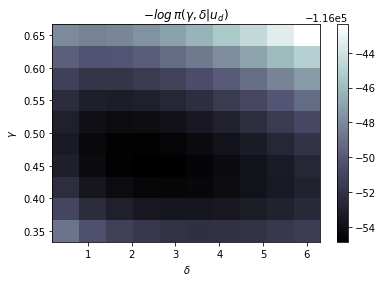

In [14]:
plt.pcolormesh(d_range,g_range,logpi)
plt.set_cmap('bone')
plt.colorbar()
plt.title(r'$-log \, \pi(\gamma, \delta | u_d)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

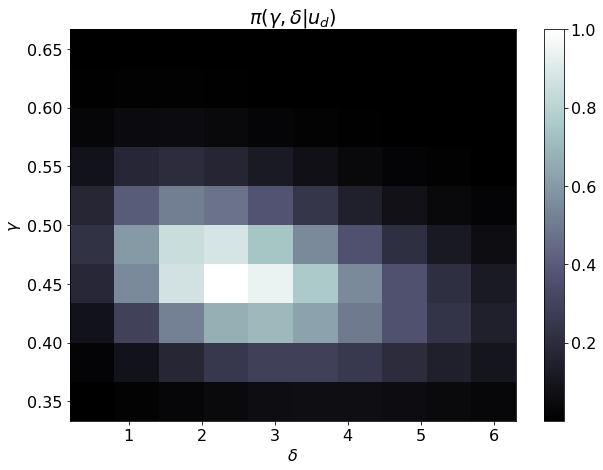

In [15]:
# scaled arbitrarily to have max value 1 in order to avoid overflow errors
fig = plt.figure(figsize=(10,7.2))
plt.rcParams.update({'font.size': 16})
plt.set_cmap('bone')
plt.pcolormesh(d_range,g_range,np.exp(-logpi+np.min(logpi)))
plt.colorbar()
# plt.title(r'$\pi(\gamma, \delta | u_d), dofs={0}$'.format(dofs))
plt.title(r'$\pi(\gamma, \delta | u_d)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')
# plt.savefig("pi_gamma_delta.pdf",bbox_inches='tight', pad_inches=0)

In [16]:
# compute MAP point of pi(gamma, delta | u_d)
def neglogpi_helper(theta):
    logpi,det,pri,uQu,muQmu = neglogpi_gamma_delta(mesh, Vh, misfit, wind_velocity, lmbda, V, pregamma, predelta, kappa, theta[0], theta[1])
    return logpi
theta0 = np.array([1, 1])
theta_opt = opt.minimize(neglogpi_helper,theta0,method='Nelder-Mead',options={'disp':True})

theta_MAP = theta_opt.x
print(theta_MAP)

Optimization terminated successfully.
         Current function value: -116054.869029
         Iterations: 51
         Function evaluations: 95
[0.45773247 2.34507287]


In [17]:
# find inverse Hessian at MAP point
# choosing the finite difference dx's here is finicky -- can't be much smaller
dgam = 1e-1 #1e-3
ddel = 8e-1 #1e-2
Hess_gg = (neglogpi_helper(theta_MAP-dgam*np.array([1,0]))
           -2*neglogpi_helper(theta_MAP)
           +neglogpi_helper(theta_MAP+dgam*np.array([1,0])))/dgam**2
Hess_gd = (neglogpi_helper(theta_MAP+dgam*np.array([1,0])+ddel*np.array([0,1]))
           +neglogpi_helper(theta_MAP)
           -neglogpi_helper(theta_MAP+dgam*np.array([1,0]))
           -neglogpi_helper(theta_MAP+ddel*np.array([0,1])))/dgam/ddel
Hess_dd = (neglogpi_helper(theta_MAP-ddel*np.array([0,1]))
           -2*neglogpi_helper(theta_MAP)
           +neglogpi_helper(theta_MAP+ddel*np.array([0,1])))/ddel**2
Hess_MAP = np.array([[Hess_gg,Hess_gd],[Hess_gd,Hess_dd]])
H_MAP_inv = np.linalg.inv(Hess_MAP)

# find principal directions
Hinv_lam,Hinv_V = np.linalg.eig(H_MAP_inv)
Hinv_L_sqrt = np.diag(np.sqrt(Hinv_lam))
def theta_of_z(z):
    return theta_MAP + np.dot(Hinv_V,np.dot(Hinv_L_sqrt,z))

In [18]:
Hinv_lam

array([0.00210749, 1.99780938])

In [23]:
# for each coordinate of z, find its values with significant probability
delta_z = 1
delta_pi = 2.5
maxiter = 20

z_highprob = [np.array([0.0]) for i in range(len(theta_MAP))]
for idx in range(len(theta_MAP)):
    z = np.array([0.0,0.0])
    z[idx] = delta_z
    count = 0
    while theta_of_z(z)[idx]>0 and neglogpi_helper(theta_of_z(z)) - neglogpi_helper(theta_MAP) < delta_pi and count < maxiter:
        z_highprob[idx] = np.append(z_highprob[idx],z[idx])
        z[idx] += delta_z
        count += 1
        print(count)
    count = 0
    z[idx] = -delta_z
    while theta_of_z(z)[idx]>0 and neglogpi_helper(theta_of_z(z)) - neglogpi_helper(theta_MAP) < delta_pi and count < maxiter:
        z_highprob[idx] = np.append(z_highprob[idx],z[idx])
        z[idx] -= delta_z
        count += 1
        print(count)

# check each pair to find quadrature points (not currently generalized to >2 parameters)
quad_points = []
for i in range(len(z_highprob[0])):
    for j in range(len(z_highprob[1])):
        theta_ij = theta_of_z(np.array([z_highprob[0][i],z_highprob[1][j]]))
        if neglogpi_helper(theta_ij) - neglogpi_helper(theta_MAP) < delta_pi:
            quad_points.append(theta_ij)
quad_points = np.array(quad_points)

1
2
1
2
1
1
2


Text(0.5, 0, '$\\delta$')

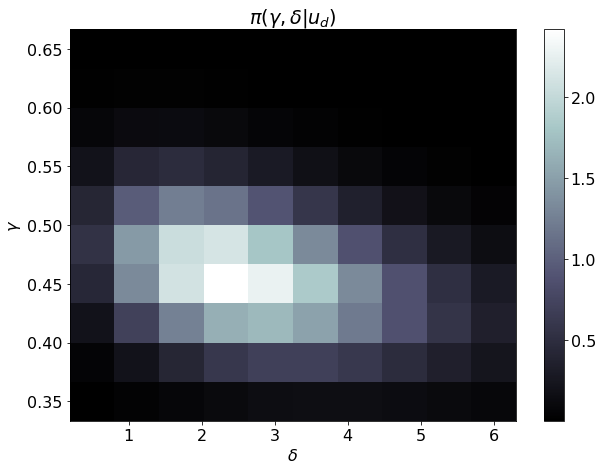

In [24]:
# approximate value of pi(gamma, delta | data) at MAP point, from Laplace approximation
scale = np.sqrt(np.linalg.det(Hess_MAP))/2/np.pi
neglogpiMAP = neglogpi_helper(theta_MAP)

fig = plt.figure(figsize=(10,7.2))
plt.rcParams.update({'font.size': 16})
plt.set_cmap('bone')
# plot scaled pi(gamma, delta | data) with quadrature points
plt.pcolormesh(d_range,g_range,np.exp(-logpi+neglogpiMAP)*scale)
plt.colorbar()
#plt.title('Quadrature points')
plt.title(r'$\pi(\gamma, \delta | u_d)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')
# plt.savefig("pi_gamma_delta.pdf",bbox_inches='tight', pad_inches=0)
# plt.axis('scaled')
# zoom = 20
# w, h = fig.get_size_inches()
# fig.set_size_inches(w * zoom, h * zoom)

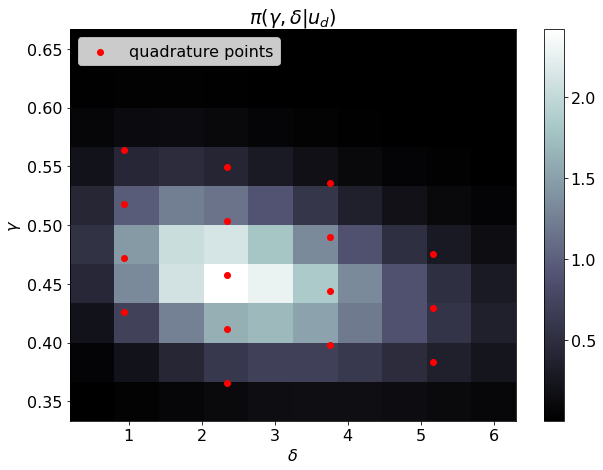

In [25]:
fig = plt.figure(figsize=(10,7.2))
plt.rcParams.update({'font.size': 16})
plt.set_cmap('bone')
# plot scaled pi(gamma, delta | data) with quadrature points
plt.pcolormesh(d_range,g_range,np.exp(-logpi+neglogpiMAP)*scale)
plt.colorbar()
plt.scatter(quad_points[:,1],quad_points[:,0],color='red',label='quadrature points') 
plt.title(r'$\pi(\gamma, \delta | u_d)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')
plt.legend(loc='upper left') #, bbox_to_anchor=(0.9, 0.3))
# plt.savefig("quad_points.pdf",bbox_inches='tight', pad_inches=0)

In [26]:
# check that pi(gamma,delta | data) integrates to ~1 using quadrature
d_area = np.sqrt(np.prod(Hinv_lam))*delta_z**2*np.linalg.norm(np.cross(np.append(Hinv_V[0],0),np.append(Hinv_V[1],0)))
total = 0
for i in range(quad_points.shape[0]):
    total += np.exp(-neglogpi_helper(quad_points[i,:])+neglogpiMAP)*scale
total*d_area

0.9454189609461136

In [ ]:
# upgrade to a finer mesh
dofs = 2779
mesh = dl.refine( dl.Mesh("adv_diff_dofs_{0}.xml".format(dofs)) )
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)

true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)

dt = dt/2
simulation_times = np.arange(t_init, t_final+.5*dt, dt)

dummy_prior = BiLaplacianPrior(Vh, 1., 8., robin_bc=True)
dummy_prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()

if weakest_precon:
    preprior = BiLaplacianPrior(Vh, pregamma, predelta, robin_bc=True)
    preprior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], preprior, misfit, simulation_times, kappa_true, wind_velocity, True)
else:
    problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], dummy_prior, misfit, simulation_times, kappa_true, wind_velocity, True)

# relative noise level
rel_noise = 0.01
# initialize vector in the state space
utrue = problem_true.generate_vector(STATE)
x = [utrue, true_initial_condition, None]
# solve forward problem
problem_true.solveFwd(x[STATE], x)
# observe solution and add error
misfit.observe(x, misfit.d)
MAX = misfit.d.norm("linf", "linf")
noise_std_dev = rel_noise * MAX
parRandom.normal_perturb(noise_std_dev,misfit.d)
misfit.noise_variance = noise_std_dev*noise_std_dev

H_misfit_only = ReducedHessian(problem_true, misfit_only=True)
k = 128
pad = 20
Omega = MultiVector(x[PARAMETER], k+pad)
parRandom.normal(1., Omega)

if weakest_precon:
    lmbda, V = singlePassG(H_misfit_only, preprior.R, preprior.Rsolver, Omega, k) 
else:
    lmbda, V = singlePass(H_misfit_only, Omega, k)
#     Bhelp = MultiVector(V) # ??

# overwriting the previous one, now for finer mesh
def neglogpi_helper(theta):
    logpi,det,pri,uQu,muQmu = neglogpi_gamma_delta(mesh, Vh, misfit, wind_velocity, lmbda, V, pregamma, predelta, kappa, theta[0], theta[1])
    return logpi
neglogpiMAP = neglogpi_helper(theta_MAP)

In [ ]:
# find pi(x^i|u_d) for each location i in locs at values x_eval of x
# in this case locations must be integer indices
def posterior_marginals(locs,u_0_eval,quad_points):
    output = np.zeros((len(locs),len(u_0_eval)))
    gauss_evals = np.zeros((len(locs),len(u_0_eval),quad_points.shape[0]))
    for idx in range(quad_points.shape[0]):
        gamma = quad_points[idx,0]
        delta = quad_points[idx,1]
        prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
        prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
        posterior,mg,lmbda_new,V_new = ComputePosterior(mesh, Vh, lmbda, V, pregamma, predelta, misfit, simulation_times, kappa, wind_velocity, gamma, delta)
        # pi(u_0^i|k,u_d)
        posterior_var,pr,corr = posterior.pointwise_variance(method="Exact")
        mm = dl.Function(Vh,posterior.mean)
        vv = dl.Function(Vh,posterior_var)
        for ii in range(len(locs)):
            for jj in range(len(u_0_eval)):
                uu = u_0_eval[jj]
                gauss_evals[ii,jj,idx] = np.exp(-(uu-mm(locs[ii]))**2/2/vv(locs[ii]))/np.sqrt(2*np.pi*vv(locs[ii]))
        # find pi(gamma, delta|u_d)
        neglogpi = neglogpi_helper(np.array([gamma,delta]))
        pi_gamma_delta = np.exp(-(neglogpi - neglogpiMAP))*scale
        
        output += d_area*pi_gamma_delta*gauss_evals[:,:,idx]
    return output,gauss_evals

In [ ]:
u_range = np.linspace(0.0,0.55,100)
locations = [[0.3,0.7],[0.45,0.55]]
true_u0_fun = dl.Function(Vh,true_initial_condition)
pi_u_0_i_evals,gauss_evals = posterior_marginals(locations,u_range,quad_points)

In [ ]:
pi_u_0_i_evals_norms = trapezoid(pi_u_0_i_evals,dx=u_range[1]-u_range[0],axis=1)
pi_u_0_i_evals_normalized = (pi_u_0_i_evals.T/pi_u_0_i_evals_norms).T
for idx in range(quad_points.shape[0]):
    gauss_evals[:,:,idx] = (gauss_evals[:,:,idx].T/pi_u_0_i_evals_norms).T
header = "x \t\t u_0_1 \t\t u_0_2"
# np.savetxt("images/pi_u_0.txt", np.column_stack((u_range, pi_u_0_i_evals_normalized.T)), delimiter="\t", header=header, fmt='%10.8f', comments="")

In [ ]:
ii = 0

plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(u_range,pi_u_0_i_evals_normalized[ii,:],linewidth=3,color='green')
plt.axvline(x=true_u0_fun(locations[ii]), color='purple', linestyle="-.", label=r"true $u_0^i$")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'Posterior Marginal Initial Condition, location {locations[ii]}')
plt.ylabel(r"$\log \pi(u_0^i|u_d)$")
plt.xlabel(r"$u_0$")
plt.tight_layout()
plt.legend()
#plt.savefig("u_0_marginal.pdf")

In [ ]:
ii = 1

plt.figure(figsize=(10,4.5))
plt.rcParams.update({'font.size': 16})
plt.plot(u_range,pi_u_0_i_evals_normalized[ii,:],linewidth=3,color='green')
plt.axvline(x=true_u0_fun(locations[ii]), color='purple', linestyle="-.", label=r"true $u_0^i$")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
plt.title(f'Posterior Marginal Initial Condition, location {locations[ii]}')
plt.ylabel(r"$\log \pi(u_0^i|u_d)$")
plt.xlabel(r"$u_0$")
plt.tight_layout()
plt.legend()
#plt.savefig("u_0_marginal.pdf")

In [ ]:
xy = mesh.coordinates()

fig = plt.figure(figsize=(10,7.2))
im = nb.plot(dl.Function(Vh,true_initial_condition),mytitle='True Initial Condition',colorbar=False)
plt.plot(locations[0][0],locations[0][1],'ro',markersize=8,label=r'$x_1$') 
#plt.plot(locations[1][0],locations[1][1],'rx') 
plt.plot(locations[1][0],locations[1][1],'rs',markersize=10,label=r'$x_2$') 
plt.legend(loc='upper right', bbox_to_anchor=(0.9, 0.3))
fig.colorbar(im, pad=0.05)
# plt.savefig("point_locations.pdf",bbox_inches='tight', pad_inches=0)